## Loading dataset

thanks to Pumi and Scott!! Here will use their method in claening unvalid/empty data!

In [ ]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import os
import kagglehub
    

# Download latest version
path = kagglehub.dataset_download("vicsuperman/prediction-of-music-genre")
raw = os.path.join(path, "music_genre.csv")

print("Path to dataset files:", path)


Path to dataset files: /Users/lipuze/.cache/kagglehub/datasets/vicsuperman/prediction-of-music-genre/versions/1


In [ ]:
# using team data cleaning code
import sys, os

sys.path.append(os.path.abspath('..'))
from data_cleaning import load_and_clean
df = load_and_clean(raw).copy()

In [ ]:
df

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,D,0.124,-7.043,Minor,0.0300,115.002,0.531,Electronic
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,B,0.106,-4.294,Major,0.3510,149.995,0.230,Electronic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35475,55.0,0.47400,0.514,246773.0,0.730,0.000000,E,0.511,-8.491,Minor,0.3870,167.655,0.699,Hip-Hop
35476,56.0,0.13300,0.849,237667.0,0.660,0.000008,C,0.296,-7.195,Major,0.0516,99.988,0.629,Hip-Hop
35477,72.0,0.15700,0.709,251860.0,0.362,0.000000,B,0.109,-9.814,Major,0.0550,122.043,0.113,Hip-Hop
35478,51.0,0.00597,0.693,189483.0,0.763,0.000000,D,0.143,-5.443,Major,0.1460,131.079,0.395,Hip-Hop


## Data Distrubution
Should we use Logitic Regression or Linear Regression to the popularity?

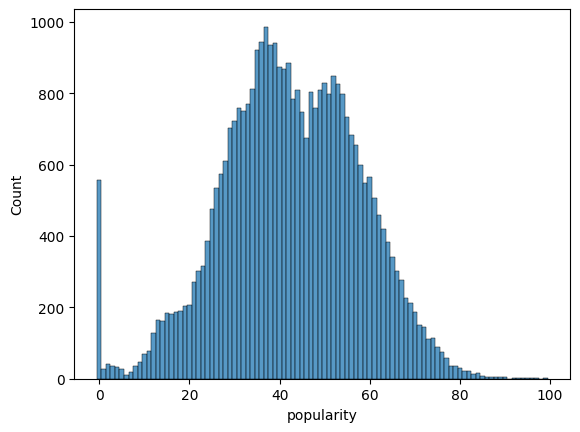

In [ ]:
# using seaborn to plot the distribution of the popularity
sns.histplot(df['popularity'], discrete=True)
plt.show()

# -> this is a single peck distrubtion

In [ ]:
# it has some zero, lets check them
df.loc[df['popularity'] == 0]

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
483,0.0,0.178000,0.702,890680.0,0.5630,0.890000,C,0.1510,-15.157,Major,0.0500,130.003,0.5810,Electronic
693,0.0,0.000019,0.534,168000.0,0.9940,0.922000,C#,0.3590,-1.947,Major,0.0460,130.034,0.0295,Electronic
2172,0.0,0.001040,0.744,360000.0,0.8600,0.687000,E,0.3150,-7.026,Minor,0.0498,129.910,0.4580,Electronic
2204,0.0,0.088800,0.800,418100.0,0.8260,0.891000,C,0.1490,-8.692,Major,0.0477,119.984,0.3420,Electronic
2230,0.0,0.068600,0.541,100339.0,0.8030,0.025500,F,0.5810,-10.165,Major,0.2910,174.069,0.2940,Electronic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32564,0.0,0.956000,0.343,385093.0,0.1200,0.000055,D,0.7240,-24.190,Major,0.0688,86.550,0.2080,Classical
32567,0.0,0.991000,0.391,85890.0,0.0362,0.881000,E,0.0955,-32.662,Major,0.0453,71.875,0.4130,Classical
32577,0.0,0.957000,0.434,151187.0,0.0872,0.000055,A#,0.7820,-26.091,Major,0.0515,78.862,0.4120,Classical
32596,0.0,0.969000,0.298,137027.0,0.0526,0.000000,G,0.5510,-27.488,Major,0.0557,85.018,0.2170,Classical


In [ ]:
# remove the zeros
df = df[df['popularity'] != 0]

df

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,D,0.124,-7.043,Minor,0.0300,115.002,0.531,Electronic
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,B,0.106,-4.294,Major,0.3510,149.995,0.230,Electronic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35475,55.0,0.47400,0.514,246773.0,0.730,0.000000,E,0.511,-8.491,Minor,0.3870,167.655,0.699,Hip-Hop
35476,56.0,0.13300,0.849,237667.0,0.660,0.000008,C,0.296,-7.195,Major,0.0516,99.988,0.629,Hip-Hop
35477,72.0,0.15700,0.709,251860.0,0.362,0.000000,B,0.109,-9.814,Major,0.0550,122.043,0.113,Hip-Hop
35478,51.0,0.00597,0.693,189483.0,0.763,0.000000,D,0.143,-5.443,Major,0.1460,131.079,0.395,Hip-Hop


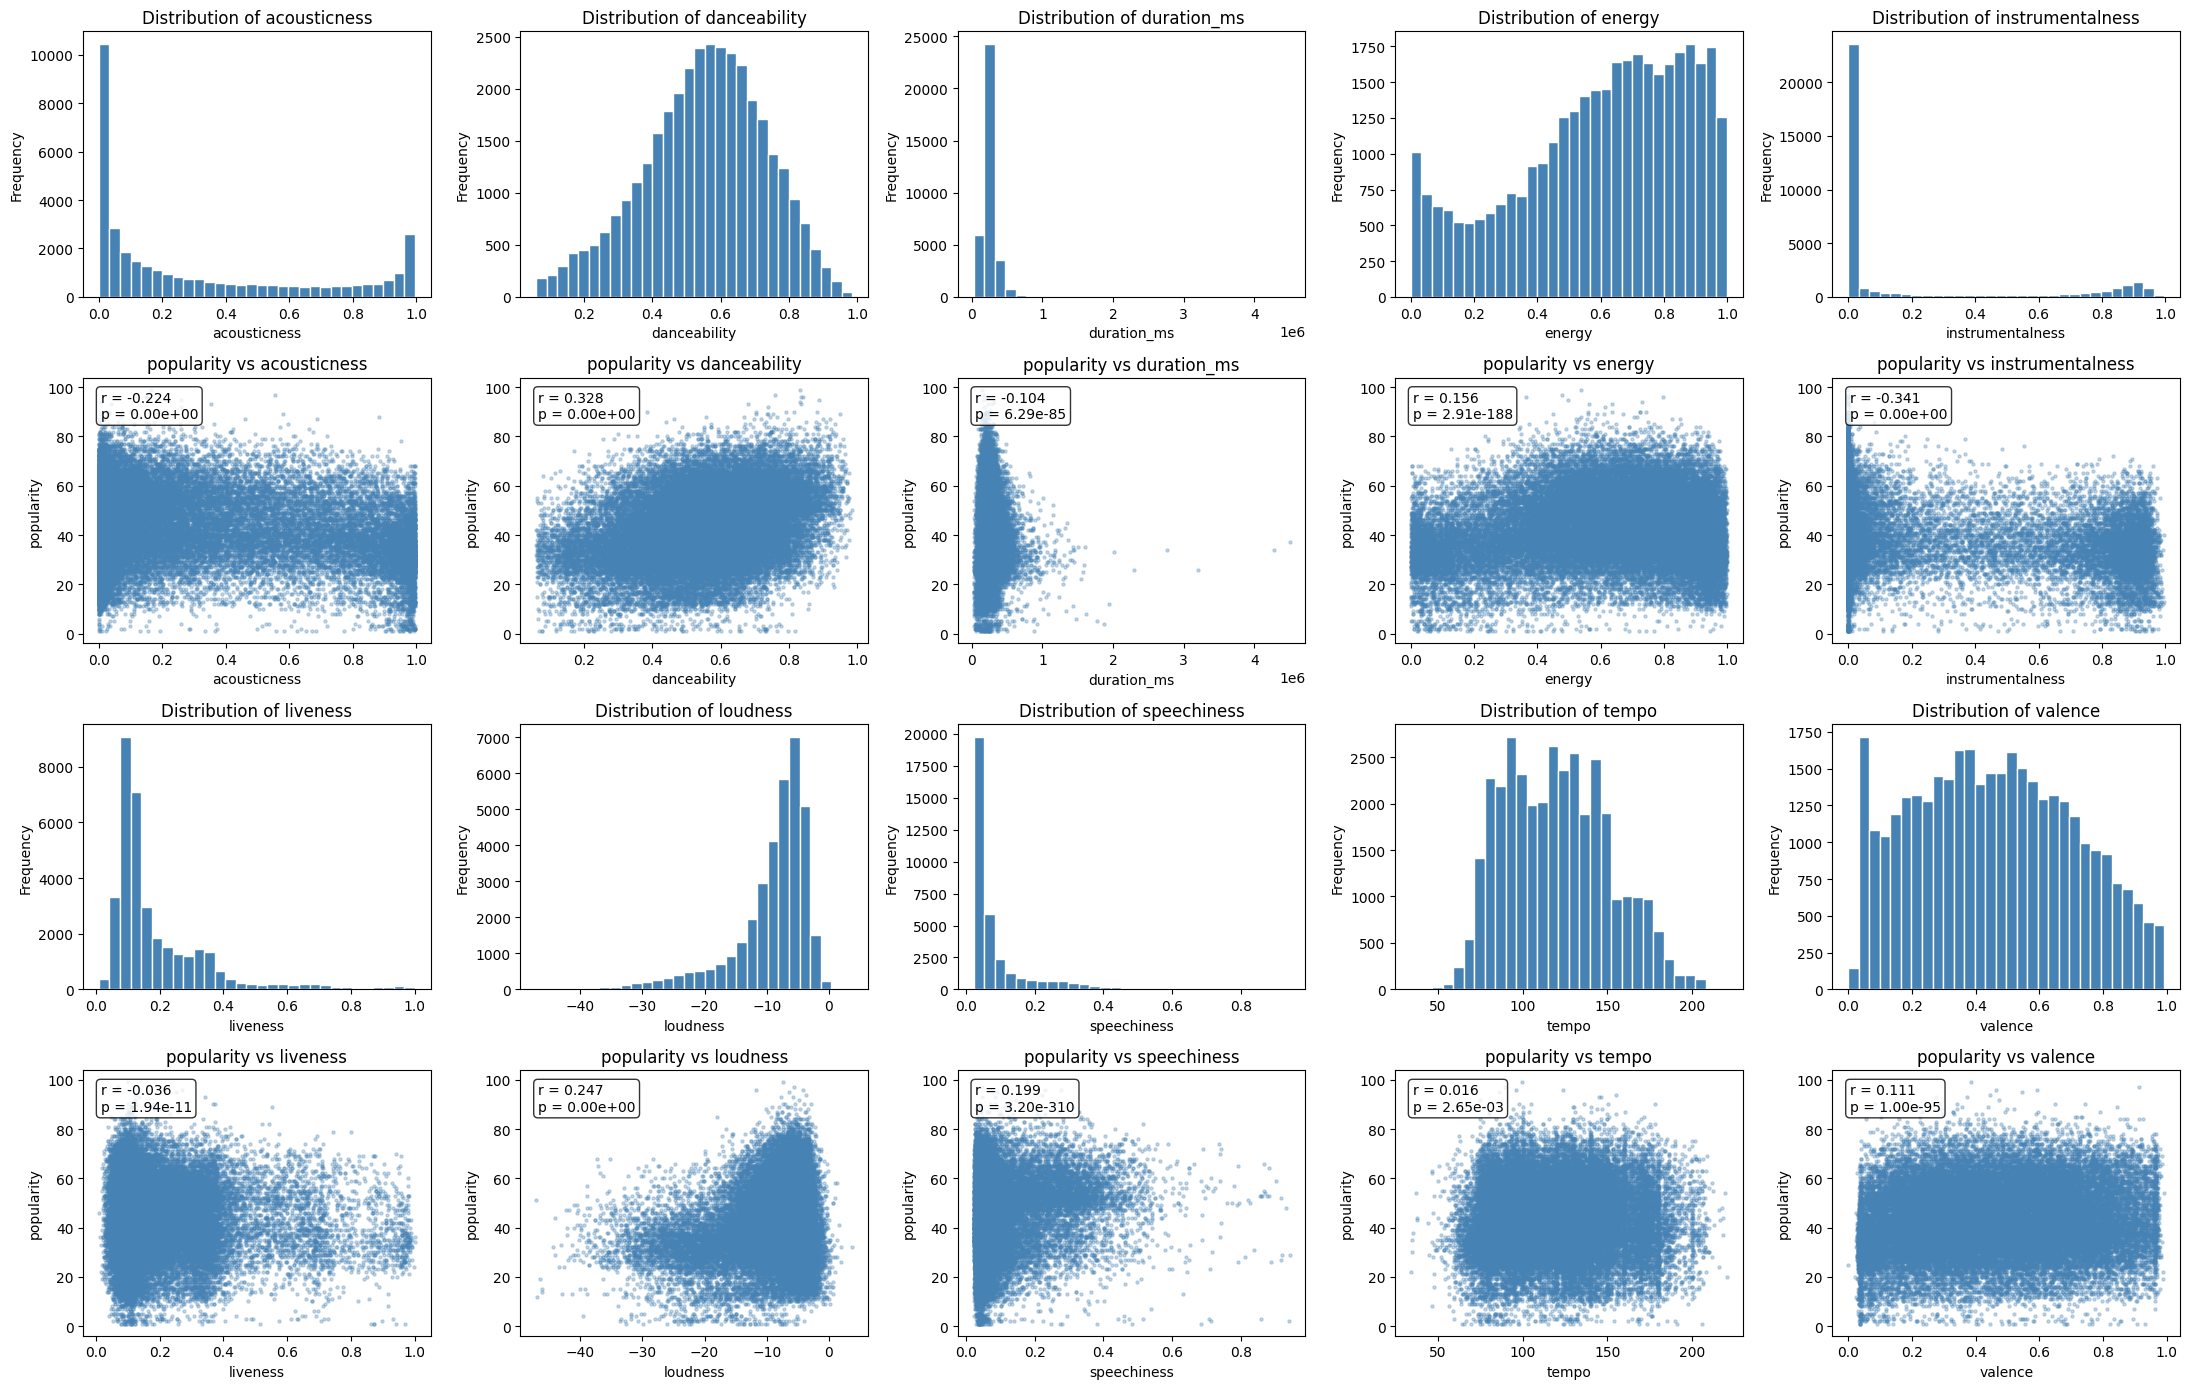

In [ ]:
from scipy.stats import pearsonr
 
features = ['acousticness','danceability','duration_ms','energy','instrumentalness',
            'liveness','loudness','speechiness','tempo','valence']
 
fig, axes = plt.subplots(4, 5, figsize=(22, 14))
 
for i, col in enumerate(features):
    row_hist = 0 if i < 5 else 2
    row_scat = 1 if i < 5 else 3
    col_idx = i % 5
 
    # histogram
    axes[row_hist, col_idx].hist(df[col].dropna(), bins=30,
                                  color='steelblue', edgecolor='white')
    axes[row_hist, col_idx].set_title(f'Distribution of {col}')
    axes[row_hist, col_idx].set_xlabel(col)
    axes[row_hist, col_idx].set_ylabel('Frequency')
 
    # scatter plot + Pearson r
    valid = df[[col, 'popularity']].dropna()
    r, p = pearsonr(valid[col], valid['popularity'])
 
    axes[row_scat, col_idx].scatter(valid[col], valid['popularity'],
                                     alpha=0.3, s=5, color='steelblue')
    axes[row_scat, col_idx].set_xlabel(col)
    axes[row_scat, col_idx].set_ylabel('popularity')
    axes[row_scat, col_idx].set_title(f'popularity vs {col}')
 
    # display Pearson r and p-value
    axes[row_scat, col_idx].text(
        0.05, 0.95,
        f'r = {r:.3f}\np = {p:.2e}',
        transform=axes[row_scat, col_idx].transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
 
plt.tight_layout()
plt.show()
 

## feature enhancement.
follow by the scott method!

#### Data encoding and feature combinition
- 'mode' is the target column but it is not numerical. `LabelEncoder` sorts labels alphabetically, so it maps Major = 0, Minor = 1.
- 
- 'key' in musical are ordered in sequence and has a cyclical nature, therefore, they can be encoded cyclically to represent this nature.

In [ ]:
df = df.copy()  # create a copy of the original DataFrame to avoid modifying it directly

In [ ]:
# Musical mode is highly related to the emotions
# it is helpful for predictions to combine emotion-related variables to create new variables.
# and also, the linear model can only capture the linear relationship, but the relationship between the features and popularity may be non-linear
#  so we can create new features by combining existing ones to capture these non-linear relationships.


df["energy_danceability"] = df["energy"] * df["danceability"]
df["valence_danceability"] = df["valence"] * df["danceability"]
df["energy_valence"] = df["energy"] * df["valence"]

In [ ]:
# musical mode is a categorical variable, we can encode it to make it usable for machine learning models.
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df["mode"] = label_encoder.fit_transform(df["mode"])

In [ ]:
df

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre,energy_danceability,valence_danceability,energy_valence
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,D,0.124,-7.043,1,0.0300,115.002,0.531,Electronic,0.553580,0.330282,0.472590
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,G#,0.534,-4.617,0,0.0345,127.994,0.333,Electronic,0.468100,0.206460,0.251415
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,C#,0.157,-4.498,0,0.2390,128.014,0.270,Electronic,0.541800,0.208980,0.189000
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,F#,0.157,-6.266,0,0.0413,145.036,0.323,Electronic,0.374506,0.206074,0.189601
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,B,0.106,-4.294,0,0.3510,149.995,0.230,Electronic,0.459316,0.131560,0.184690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35475,55.0,0.47400,0.514,246773.0,0.730,0.000000,E,0.511,-8.491,1,0.3870,167.655,0.699,Hip-Hop,0.375220,0.359286,0.510270
35476,56.0,0.13300,0.849,237667.0,0.660,0.000008,C,0.296,-7.195,0,0.0516,99.988,0.629,Hip-Hop,0.560340,0.534021,0.415140
35477,72.0,0.15700,0.709,251860.0,0.362,0.000000,B,0.109,-9.814,0,0.0550,122.043,0.113,Hip-Hop,0.256658,0.080117,0.040906
35478,51.0,0.00597,0.693,189483.0,0.763,0.000000,D,0.143,-5.443,0,0.1460,131.079,0.395,Hip-Hop,0.528759,0.273735,0.301385


In [ ]:
# 'key' in musical are ordered in sequence and has a cyclical nature, therefore, they can be encoded cyclically to represent this nature.
df["key"] = label_encoder.fit_transform(df["key"])
df["key_sin"] = np.sin(2 * np.pi * df["key"] / 12)
df["key_cos"] = np.cos(2 * np.pi * df["key"] / 12)
df = df.drop(columns=["key"])

In [ ]:
# Ensure a continuous index after row filtering so later assignments align by row position.
df = df.reset_index(drop=True)
df

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,mode,speechiness,tempo,valence,music_genre,energy_danceability,valence_danceability,energy_valence,key_sin,key_cos
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,0.124,-7.043,1,0.0300,115.002,0.531,Electronic,0.553580,0.330282,0.472590,0.500000,-8.660254e-01
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,0.534,-4.617,0,0.0345,127.994,0.333,Electronic,0.468100,0.206460,0.251415,-0.500000,8.660254e-01
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,0.157,-4.498,0,0.2390,128.014,0.270,Electronic,0.541800,0.208980,0.189000,0.866025,-5.000000e-01
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,0.157,-6.266,0,0.0413,145.036,0.323,Electronic,0.374506,0.206074,0.189601,-1.000000,-1.836970e-16
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,0.106,-4.294,0,0.3510,149.995,0.230,Electronic,0.459316,0.131560,0.184690,0.866025,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34919,55.0,0.47400,0.514,246773.0,0.730,0.000000,0.511,-8.491,1,0.3870,167.655,0.699,Hip-Hop,0.375220,0.359286,0.510270,-0.500000,-8.660254e-01
34920,56.0,0.13300,0.849,237667.0,0.660,0.000008,0.296,-7.195,0,0.0516,99.988,0.629,Hip-Hop,0.560340,0.534021,0.415140,1.000000,6.123234e-17
34921,72.0,0.15700,0.709,251860.0,0.362,0.000000,0.109,-9.814,0,0.0550,122.043,0.113,Hip-Hop,0.256658,0.080117,0.040906,0.866025,5.000000e-01
34922,51.0,0.00597,0.693,189483.0,0.763,0.000000,0.143,-5.443,0,0.1460,131.079,0.395,Hip-Hop,0.528759,0.273735,0.301385,0.500000,-8.660254e-01


In [ ]:
# one-hot encode the 'genre' column
df['music_genre_orig'] = df['music_genre']
df = pd.get_dummies(df, columns=['music_genre'], prefix='genre')
df

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,mode,speechiness,...,genre_Alternative,genre_Anime,genre_Blues,genre_Classical,genre_Country,genre_Electronic,genre_Hip-Hop,genre_Jazz,genre_Rap,genre_Rock
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,0.124,-7.043,1,0.0300,...,False,False,False,False,False,True,False,False,False,False
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,0.534,-4.617,0,0.0345,...,False,False,False,False,False,True,False,False,False,False
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,0.157,-4.498,0,0.2390,...,False,False,False,False,False,True,False,False,False,False
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,0.157,-6.266,0,0.0413,...,False,False,False,False,False,True,False,False,False,False
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,0.106,-4.294,0,0.3510,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34919,55.0,0.47400,0.514,246773.0,0.730,0.000000,0.511,-8.491,1,0.3870,...,False,False,False,False,False,False,True,False,False,False
34920,56.0,0.13300,0.849,237667.0,0.660,0.000008,0.296,-7.195,0,0.0516,...,False,False,False,False,False,False,True,False,False,False
34921,72.0,0.15700,0.709,251860.0,0.362,0.000000,0.109,-9.814,0,0.0550,...,False,False,False,False,False,False,True,False,False,False
34922,51.0,0.00597,0.693,189483.0,0.763,0.000000,0.143,-5.443,0,0.1460,...,False,False,False,False,False,False,True,False,False,False


### select features

In [ ]:
X = df.drop(columns=['popularity', "music_genre_orig"])
y = df['popularity']

Mutual Information Scores for Features:
                 Feature  MI Score
17           genre_Anime  0.153650
4       instrumentalness  0.104857
25            genre_Rock  0.099554
24             genre_Rap  0.084677
6               loudness  0.075748
22         genre_Hip-Hop  0.072955
1           danceability  0.072751
11   energy_danceability  0.065539
0           acousticness  0.064482
3                 energy  0.064349
18           genre_Blues  0.056108
16     genre_Alternative  0.054934
13        energy_valence  0.048908
19       genre_Classical  0.047901
20         genre_Country  0.046022
12  valence_danceability  0.043525
2            duration_ms  0.040246
23            genre_Jazz  0.036406
8            speechiness  0.034889
21      genre_Electronic  0.030128
10               valence  0.026397
9                  tempo  0.016576
5               liveness  0.012339
15               key_cos  0.004634
14               key_sin  0.003913
7                   mode  0.000000


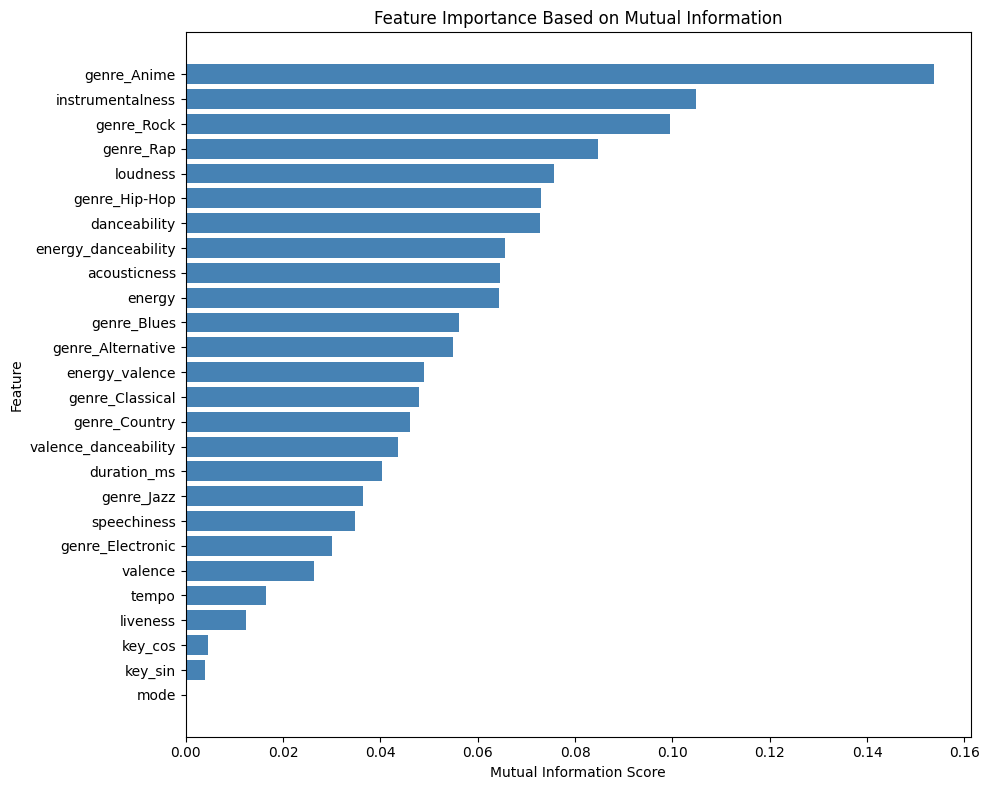

In [ ]:
# using SelectKBast to select top 15 features
from sklearn.feature_selection import mutual_info_regression
discrete_features = X.columns.str.startswith(('key_', 'mode_', 'genre_'))

mi_scores = mutual_info_regression(
    X,
    y,
    discrete_features=discrete_features,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI Score', ascending=False)

print("Mutual Information Scores for Features:")
print(mi_df)

plt.figure(figsize=(10, 8))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='steelblue')

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance Based on Mutual Information")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


The Music Genre has very high mutual information score with popularity. That is quite resonable for Anime songs truly always has less chance to be popularity than Jazz. And we will dissguess this later, and we will try two data, one is with the genre, one is without the genre.

And these feature MI score are very low, so lets drop them. 
- mode (MI = 0)
- key_sin, key_cos (MI ≈ 0)
- liveness, tempo (MI < 0.02)

In [ ]:
X = X.drop(columns=['mode', 'liveness', 'key_sin', 'key_cos', 'tempo'])

Lets deal with relations between metrics.

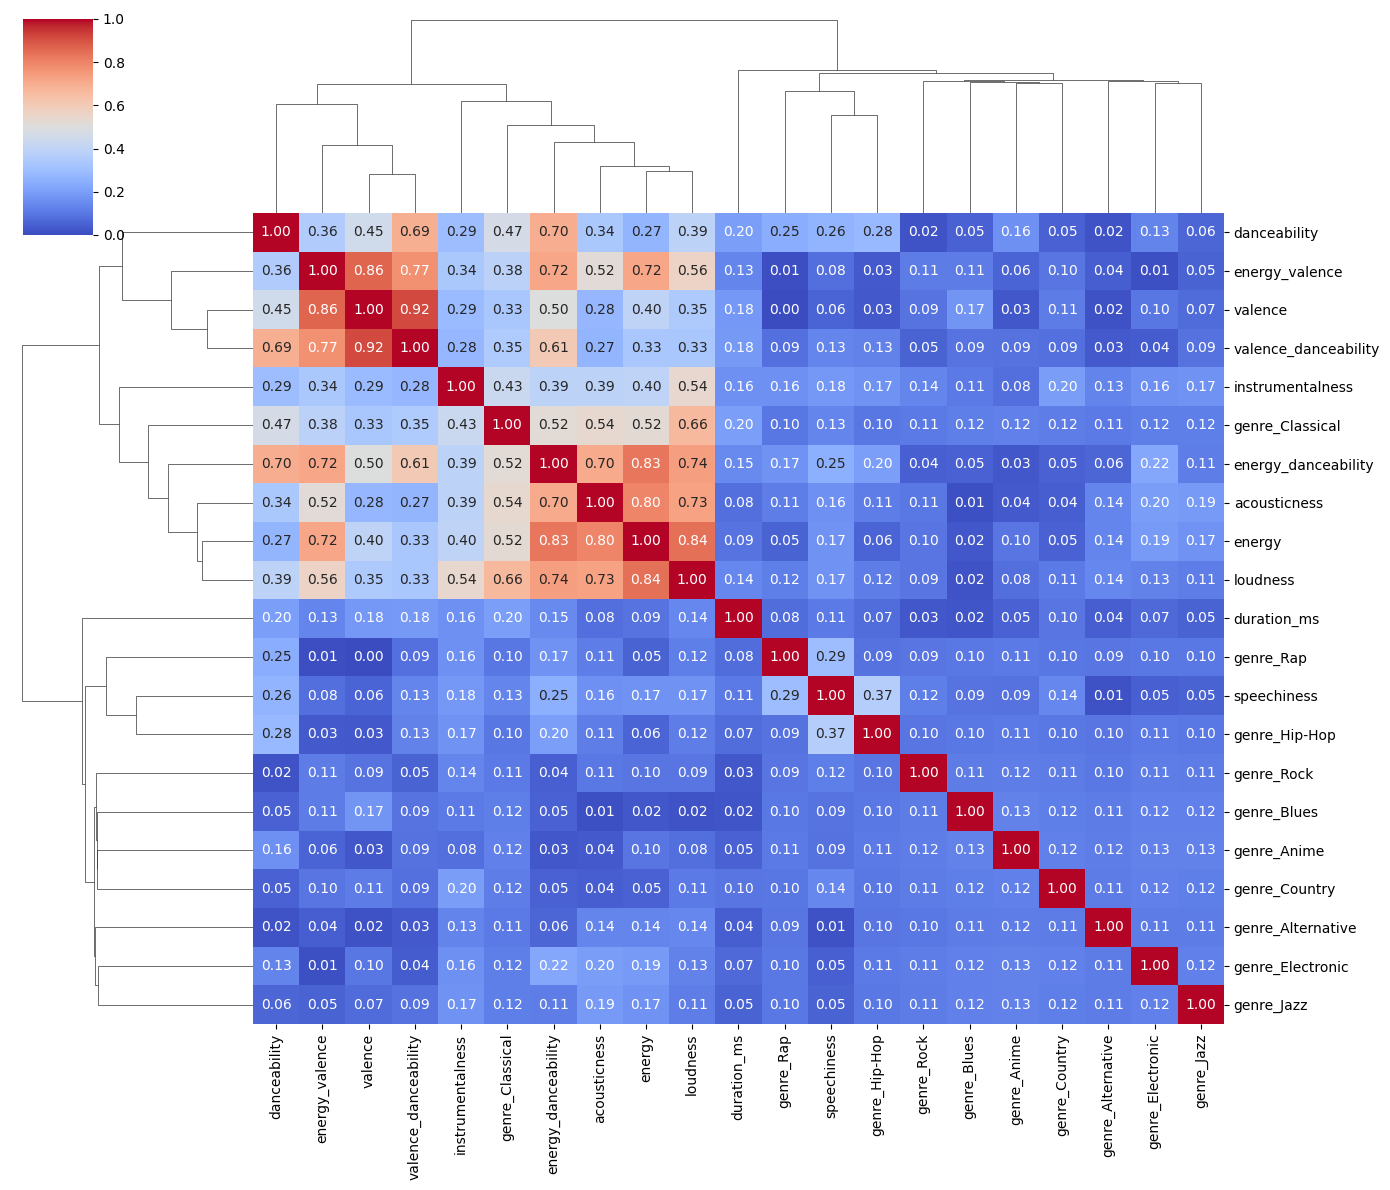

In [ ]:
corr_matrix = X.corr().abs()

sns.clustermap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f',
               figsize=(14, 12), vmin=0, vmax=1)
plt.show()

In [ ]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
pairs = corr_matrix.where(mask).stack().sort_values(ascending=False)

print(pairs.head(20))

valence               valence_danceability    0.917923
                      energy_valence          0.863938
energy                loudness                0.839886
                      energy_danceability     0.830820
acousticness          energy                  0.797065
valence_danceability  energy_valence          0.771844
loudness              energy_danceability     0.738170
acousticness          loudness                0.729337
energy                energy_valence          0.715987
energy_danceability   energy_valence          0.715713
acousticness          energy_danceability     0.703538
danceability          energy_danceability     0.696633
                      valence_danceability    0.692228
loudness              genre_Classical         0.662618
energy_danceability   valence_danceability    0.607944
loudness              energy_valence          0.563197
instrumentalness      loudness                0.539462
acousticness          genre_Classical         0.536561
energy    

The 3 combined feature, are highly corrected with the original feature. and these conbined feature don't show higher MI score than original features. So lets drop them.
Drop: 
- valence_danceability
- energy_valence
- energy_danceability


In [ ]:
X = X.drop(columns=['valence_danceability', 'energy_danceability', 'energy_valence'])

In [ ]:
X

,acousticness,danceability,duration_ms,energy,instrumentalness,loudness,speechiness,valence,genre_Alternative,genre_Anime,genre_Blues,genre_Classical,genre_Country,genre_Electronic,genre_Hip-Hop,genre_Jazz,genre_Rap,genre_Rock
0,0.01270,0.622,218293.0,0.890,0.950000,-7.043,0.0300,0.531,False,False,False,False,False,True,False,False,False,False
1,0.00306,0.620,215613.0,0.755,0.011800,-4.617,0.0345,0.333,False,False,False,False,False,True,False,False,False,False
2,0.02540,0.774,166875.0,0.700,0.002530,-4.498,0.2390,0.270,False,False,False,False,False,True,False,False,False,False
3,0.00465,0.638,222369.0,0.587,0.909000,-6.266,0.0413,0.323,False,False,False,False,False,True,False,False,False,False
4,0.02890,0.572,214408.0,0.803,0.000008,-4.294,0.3510,0.230,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34919,0.47400,0.514,246773.0,0.730,0.000000,-8.491,0.3870,0.699,False,False,False,False,False,False,True,False,False,False
34920,0.13300,0.849,237667.0,0.660,0.000008,-7.195,0.0516,0.629,False,False,False,False,False,False,True,False,False,False
34921,0.15700,0.709,251860.0,0.362,0.000000,-9.814,0.0550,0.113,False,False,False,False,False,False,True,False,False,False
34922,0.00597,0.693,189483.0,0.763,0.000000,-5.443,0.1460,0.395,False,False,False,False,False,False,True,False,False,False


Finally, we keep 18 features.

### Data Split and Scale

Text(0, 0.5, 'Frequency')

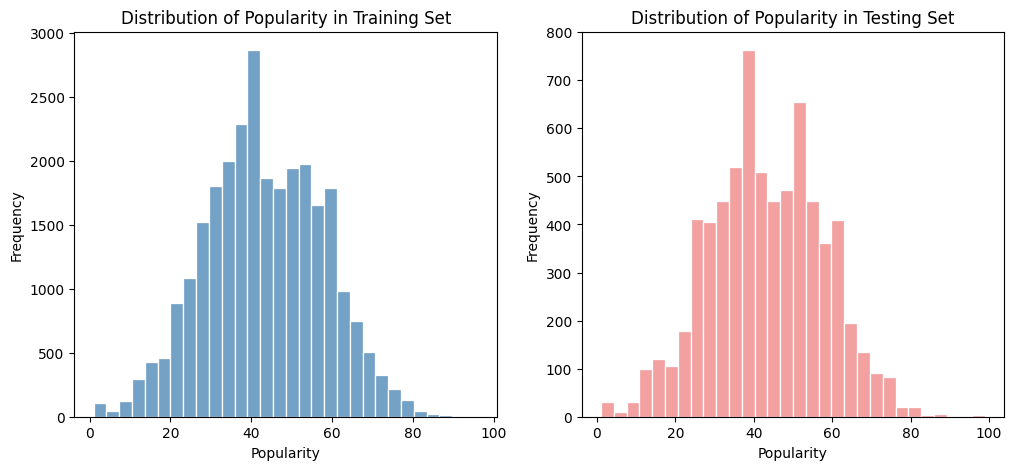

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame and 'popularity' is the target variable
y_binned = pd.qcut(y, q=20, labels=False, duplicates='drop')
#  qcut = quantile-based discretization function, which divides the data into equal-sized bins based on quantiles.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_binned
)

## plot the distribution of the target variable in the training and testing sets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(y_train, bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Popularity in Training Set')
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Frequency') 

sns.histplot(y_test, bins=30, ax=axes[1], color='lightcoral', edgecolor='white')
axes[1].set_title('Distribution of Popularity in Testing Set')
axes[1].set_xlabel('Popularity')
axes[1].set_ylabel('Frequency') 

In [ ]:
# check the music genre distribution in the training and testing sets
train_genre_cols = [c for c in X_train.columns if c.startswith("genre_")]
test_genre_cols  = [c for c in X_test.columns  if c.startswith("genre_")]
for col in train_genre_cols:
    train_count = X_train[col].sum()
    test_count = X_test[col].sum()
    print(f"{col}: Train count = {train_count}, Test count = {test_count}")

genre_Alternative: Train count = 2623, Test count = 639
genre_Anime: Train count = 3195, Test count = 822
genre_Blues: Train count = 3064, Test count = 712
genre_Classical: Train count = 2838, Test count = 726
genre_Country: Train count = 2975, Test count = 738
genre_Electronic: Train count = 3077, Test count = 780
genre_Hip-Hop: Train count = 2277, Test count = 600
genre_Jazz: Train count = 3035, Test count = 772
genre_Rap: Train count = 2234, Test count = 535
genre_Rock: Train count = 2621, Test count = 661


In [ ]:
# create a special X, which dosen't have the one-hot encoded genre features, to be used for linear regression
genre_cols = [c for c in X.columns if c.startswith("genre_")]
X_no_genre = X.drop(columns=genre_cols)
X_train_no_genre = X_train.drop(columns=genre_cols)
X_test_no_genre = X_test.drop(columns=genre_cols)

In [ ]:
X_train_no_genre

,acousticness,danceability,duration_ms,energy,instrumentalness,loudness,speechiness,valence
23176,0.994000,0.738,136693.0,0.3390,0.300000,-9.701,0.0641,0.424
29541,0.991000,0.221,776200.0,0.0582,0.910000,-26.820,0.0364,0.040
3836,0.000051,0.806,404205.0,0.4920,0.897000,-11.040,0.0797,0.546
10707,0.806000,0.260,161640.0,0.4900,0.000000,-9.121,0.0415,0.399
11410,0.780000,0.700,182656.0,0.4860,0.000021,-6.869,0.0369,0.673
...,...,...,...,...,...,...,...,...
11334,0.121000,0.602,216647.0,0.7050,0.000000,-4.868,0.0641,0.557
18407,0.233000,0.551,190867.0,0.6110,0.000000,-6.153,0.0262,0.505
26252,0.224000,0.161,102267.0,0.8360,0.080200,-9.324,0.0519,0.487
18934,0.591000,0.797,121630.0,0.2930,0.072400,-7.479,0.0800,0.478


In [ ]:
# create scale pipeline, keep the one-hot encoded genre columns unchanged, and only scale the numerical columns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ['acousticness', 'danceability', 'duration_ms', 'energy',
            'instrumentalness', 'loudness', 'speechiness', 'valence']
ohe_cols = [c for c in X.columns if c.startswith('genre_')]

pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('ohe', 'passthrough', ohe_cols), 
])

pre_no_genre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
])


## Linear Regression

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [204]:
corr = X_train.corrwith(y_train).sort_values(ascending=False)
print(corr)

genre_Rock           0.366024
genre_Rap            0.354163
danceability         0.326542
genre_Hip-Hop        0.296611
loudness             0.243151
speechiness          0.196964
energy               0.153683
genre_Alternative    0.140539
valence              0.112382
genre_Country        0.058595
genre_Jazz          -0.052578
duration_ms         -0.103776
genre_Electronic    -0.125806
genre_Blues         -0.213069
acousticness        -0.222861
genre_Classical     -0.238559
instrumentalness    -0.338058
genre_Anime         -0.466958
dtype: float64


In [ ]:
pipe_lr = Pipeline([
    ('pre', pre),
    ('clf', LinearRegression()),
])

## for linear regression, we don't have hyperparameters to tune
# train directly without tuning
pipe_lr.fit(X_train, y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ohe', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
!pip install statsmodels

In [207]:
#result print

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

def print_regression_results(pipeline, X_train=X_train, y_train=y_train,
                             X_test=X_test, y_test=y_test, name = None):
    
    if isinstance(pipeline, GridSearchCV):
        search = pipeline
        pipeline = search.best_estimator_
        print(f'Best params : {search.best_params_}')
        print(f'Best CV R²  : {search.best_score_:.4f}')
    
    if hasattr(pipeline, 'steps'):
        model_name = name or pipeline.steps[-1][1].__class__.__name__
    else:
        model_name = name or pipeline.__class__.__name__

    y_pred = pipeline.predict(X_test)

    train_r2 = pipeline.score(X_train, y_train)
    test_r2  = pipeline.score(X_test, y_test)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f'[{model_name}]')
    print(f'train R² : {train_r2:.4f}')
    print(f'test  R² : {test_r2:.4f}')
    print(f'RMSE     : {rmse:.4f}')
    print(f'MSE      : {mse:.4f}')

    fig, ax = plt.subplots()
    sns.regplot(x=y_pred, y=y_test, lowess=True, ax=ax,
                scatter_kws={'alpha': 0.5, 's': 20},
                line_kws={'color': 'red', 'lw': 1.5})

    lims = [min(y_pred.min(), y_test.min()), max(y_pred.max(), y_test.max())]
    ax.plot(lims, lims, color='gray', ls='--', lw=1, label='y = x (ideal)')
    ax.plot([], [], color='red', lw=1.5, label='LOWESS fit')

    txt = f'$R^2$ = {test_r2:.4f}\nRMSE = {rmse:.4f}\nMSE = {mse:.4f}'
    ax.text(0.05, 0.95, txt, transform=ax.transAxes,
            va='top', ha='left', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white',
                      alpha=0.8, edgecolor='gray'))

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name}  |  Predicted vs Actual')
    ax.legend(loc='lower right')
    plt.show()
    
    fig, ax = plt.subplots()
    sns.residplot(x=y_pred, y=y_test - y_pred, lowess=True, ax=ax,
                  scatter_kws={'alpha': 0.5, 's': 20},
                  line_kws={'color': 'red', 'lw': 1.5})
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    ax.set_title(f'{model_name}  |  Residual Plot')
    plt.show()

[LinearRegression]
train R² : 0.6438
test  R² : 0.6386
RMSE     : 8.7730
MSE      : 76.9656


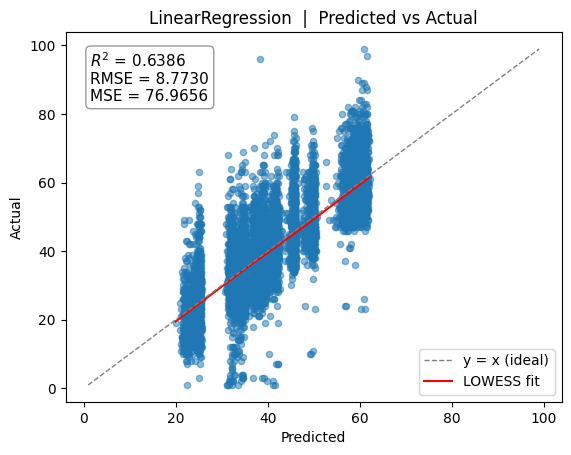

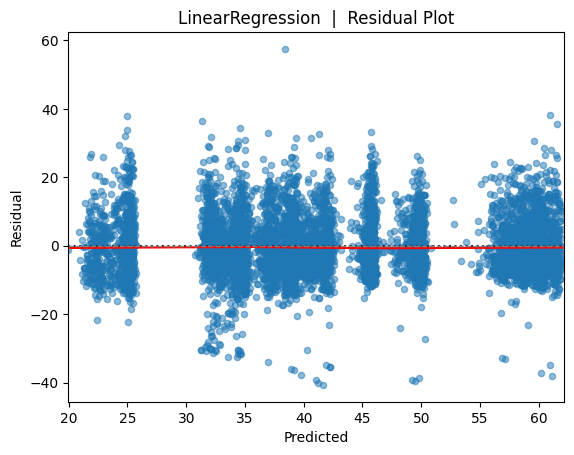

In [ ]:
print_regression_results(pipe_lr)

The linear regression model achieves a test R² of 0.639, with a train R² of 0.644. The gap between training and test scores is negligible (~0.005), indicating that the model generalizes well and shows no signs of overfitting. 
And for the Vertical clustering:This is a structural artifact of fitting a linear model on data dominated by strong categorical features, like music genre where each category contributes a fixed offset to the prediction. 

In [ ]:
pipe_ridge = Pipeline([
    ('pre', pre),
    ('reg', Ridge()),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)


param_grid = {'reg__alpha':[0.01, 0.1, 1, 10, 100, 1000, 10000]}

gs_ridge = GridSearchCV(
    pipe_ridge, param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True,
)
gs_ridge.fit(X_train, y_train)

,estimator,"Pipeline(step...g', Ridge())])"
,param_grid,"{'reg__alpha': [0.01, 0.1, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('ohe', ...)]"


In [ ]:
def plot_grid_search(gs, score_label='CV score', title=None, figsize=None):
    """
    Visualize GridSearchCV / RandomizedSearchCV results.

    - 1 hyperparameter  → line plot with error bars
    - 2 hyperparameters → heatmap
    - 3+ hyperparameters → small-multiples: heatmaps faceted by extra params
    """
    res = pd.DataFrame(gs.cv_results_)

    param_cols = [c for c in res.columns if c.startswith('param_')]
    param_cols = [c for c in param_cols if res[c].nunique() > 1]

    if not param_cols:
        print('No hyperparameter was varied.')
        return

    for c in param_cols:
        res[c] = res[c].astype(str)

    short_names = [c.replace('param_', '').split('__')[-1] for c in param_cols]
    rename_map = dict(zip(param_cols, short_names))
    res = res.rename(columns=rename_map)

    n = len(short_names)

    # ===== 1D =====
    if n == 1:
        p = short_names[0]
        sub = res[[p, 'mean_test_score', 'std_test_score']].copy()
        sub = sub.sort_values(p)

        plt.figure(figsize=figsize or (7, 4))
        plt.errorbar(sub[p], sub['mean_test_score'], yerr=sub['std_test_score'],
                     marker='o', capsize=3)
        plt.ylim(0.5, 0.8)
        plt.xlabel(p); plt.ylabel(score_label)
        plt.title(title or f'GridSearchCV over {p}')
        plt.xticks(rotation=30)
        plt.tight_layout(); plt.show()
        return

    # ===== 2D =====
    if n == 2:
        p1, p2 = short_names
        pivot = res.pivot_table(index=p1, columns=p2, values='mean_test_score', aggfunc='mean')

        plt.figure(figsize=figsize or (8, 4))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', vmin=0.5, vmax=0.8)
        plt.title(title or f'{score_label} across {p1} × {p2}')
        plt.tight_layout(); plt.show()
        return

    # ===== 3 =====
    if n >= 3:
        return

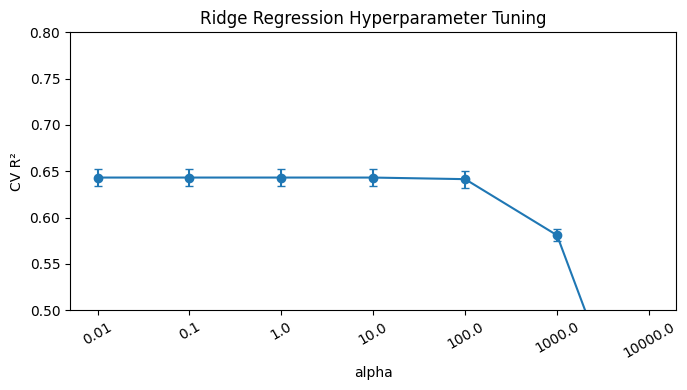

In [ ]:
plot_grid_search(gs_ridge, score_label='CV R²', title='Ridge Regression Hyperparameter Tuning')

In [ ]:
gs_ridge.best_params_

{'reg__alpha': 1}

that means, the ridge are very similar to the linear model, for that punishment is to small for the final score.

Best params : {'reg__alpha': 1}
Best CV R²  : 0.6432
[Ridge]
train R² : 0.6438
test  R² : 0.6386
RMSE     : 8.7729
MSE      : 76.9641


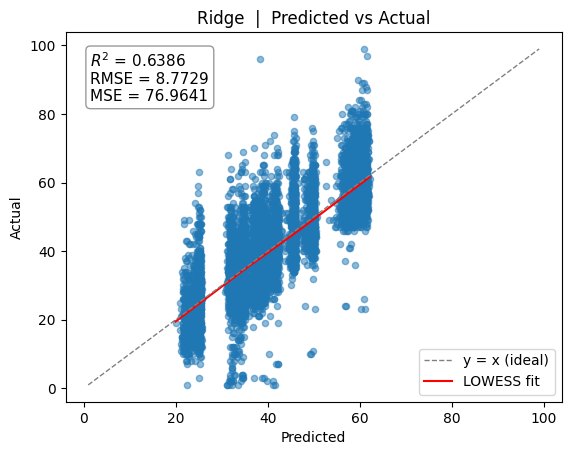

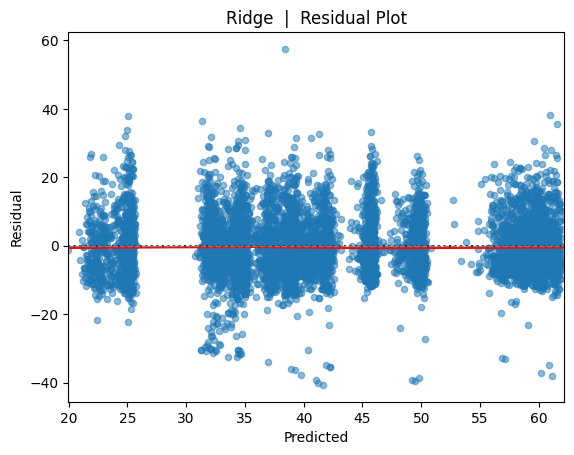

In [ ]:
print_regression_results(gs_ridge)

In [ ]:
# lets check the performance of linear regression without the one-hot encoded genre features, to see how much the genre features contribute to the predictions
pipe_lr_no_genre = Pipeline([
    ('pre', pre_no_genre),
    ('clf', LinearRegression()),
])
pipe_lr_no_genre.fit(X_train_no_genre, y_train) 

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


[Linear Regression (no genre)]
train R² : 0.1909
test  R² : 0.2038
RMSE     : 13.0206
MSE      : 169.5359


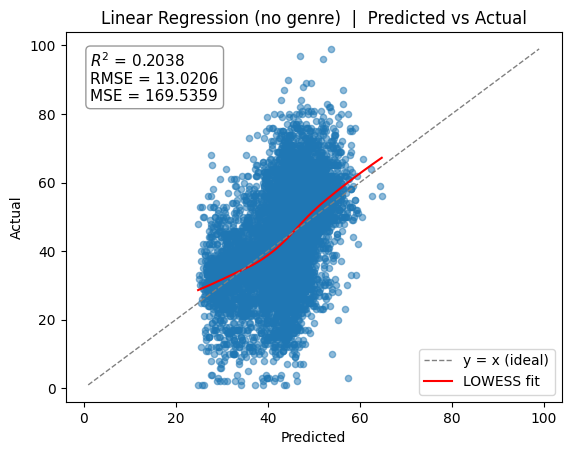

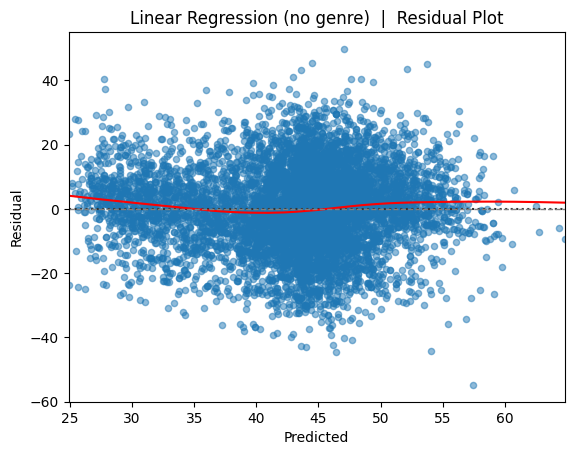

In [ ]:
print_regression_results(pipe_lr_no_genre, X_train_no_genre, y_train, X_test_no_genre, y_test, name='Linear Regression (no genre)')

that means, the music genre is very important, and cause main influence in the linear model.

In [ ]:
best_rf = gs_rf.best_estimator_.named_steps['reg']
feat_names = gs_rf.best_estimator_.named_steps['pre'].get_feature_names_out()
imp = pd.DataFrame({'feature': feat_names, 'importance': best_rf.feature_importances_})
print(imp.sort_values('importance', ascending=False).head(15))

                   feature  importance
9         ohe__genre_Anime    0.312519
17         ohe__genre_Rock    0.126296
4    num__instrumentalness    0.121969
14      ohe__genre_Hip-Hop    0.097650
16          ohe__genre_Rap    0.091107
10        ohe__genre_Blues    0.091092
8   ohe__genre_Alternative    0.041094
12      ohe__genre_Country    0.018144
11    ohe__genre_Classical    0.018105
5            num__loudness    0.012976
2         num__duration_ms    0.011563
6         num__speechiness    0.010565
0        num__acousticness    0.009557
1        num__danceability    0.008994
7             num__valence    0.008339


Text(0.5, 1.0, 'Popularity Distribution by Music Genre')

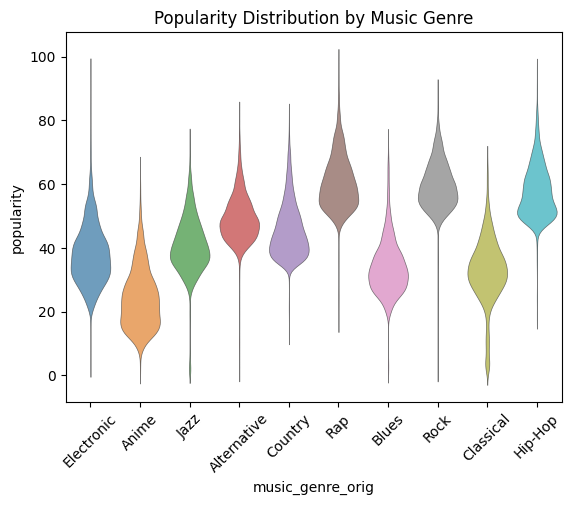

In [ ]:
import seaborn as sns
sns.violinplot(data=df, x='music_genre_orig', y='popularity',
               hue='music_genre_orig', palette='tab10',
               inner=None, linewidth=0.5, alpha=0.7, legend=False)
plt.xticks(rotation=45)
plt.title('Popularity Distribution by Music Genre')

## Decision Tree

In [218]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
import numpy as np


In [ ]:
pipe_dt = Pipeline([
    ('pre', pre),
    ('reg', DecisionTreeRegressor(random_state=42)),
])

param_grid_dt = {
    'reg__max_depth': [5,10,15,None],
    'reg__min_samples_leaf': [1,5,10, 100, 300, 500], 
}

gs_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=cv, scoring='r2', n_jobs=-1)
gs_dt.fit(X_train, y_train)

print('DT best params:', gs_dt.best_params_)
print('DT train R²:', gs_dt.score(X_train, y_train))
print('DT test  R²:', gs_dt.score(X_test, y_test))

DT best params: {'reg__max_depth': 10, 'reg__min_samples_leaf': 100}
DT train R²: 0.6599122301852188
DT test  R²: 0.6377802699368114


Best params : {'reg__max_depth': 10, 'reg__min_samples_leaf': 100}
Best CV R²  : 0.6416
[DecisionTreeRegressor]
train R² : 0.6599
test  R² : 0.6378
RMSE     : 8.7825
MSE      : 77.1315


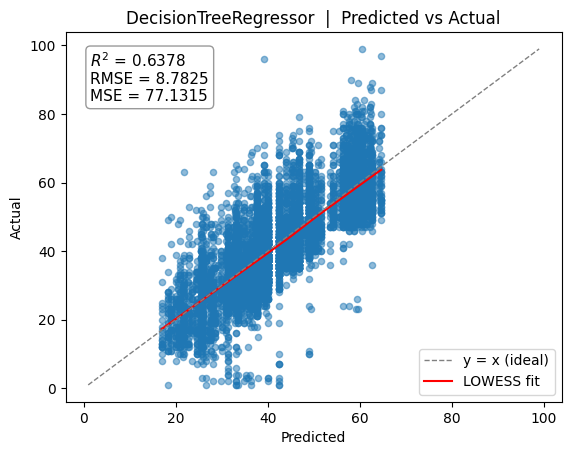

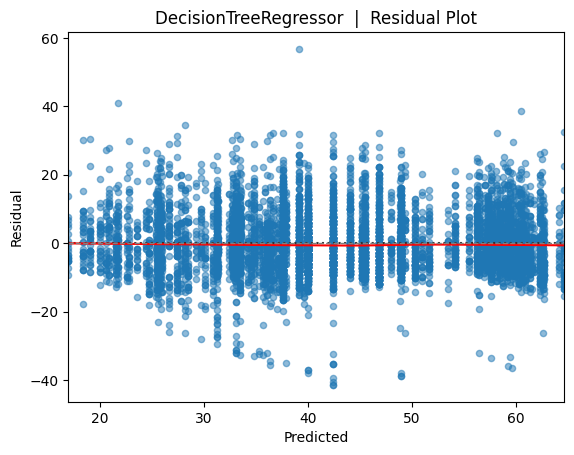

In [220]:
print_regression_results(gs_dt)

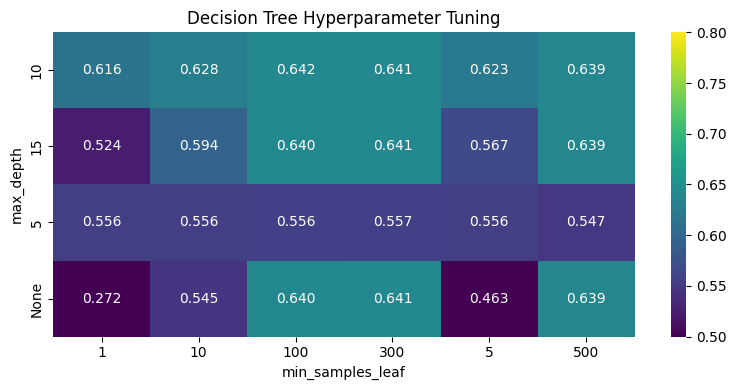

In [ ]:
plot_grid_search(gs_dt, score_label='CV R²', title='Decision Tree Hyperparameter Tuning')

## Random Forest, HistGradientBoosting

In [ ]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

In [ ]:
pipe_rf = Pipeline([
    ('pre', pre),
    ('reg', RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_grid_rf = {
    'reg__n_estimators': [100, 200, 500],
    'reg__max_depth': [10, 20, None],
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv, scoring='r2', n_jobs=-1)
gs_rf.fit(X_train, y_train)

print('RF best params:', gs_rf.best_params_)
print('RF train R²:', gs_rf.score(X_train, y_train))
print('RF test  R²:', gs_rf.score(X_test, y_test))

/Users/lipuze/miniconda3/envs/brain/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RF best params: {'reg__max_depth': 10, 'reg__n_estimators': 500}
RF train R²: 0.6981414236185024
RF test  R²: 0.6481461001653868


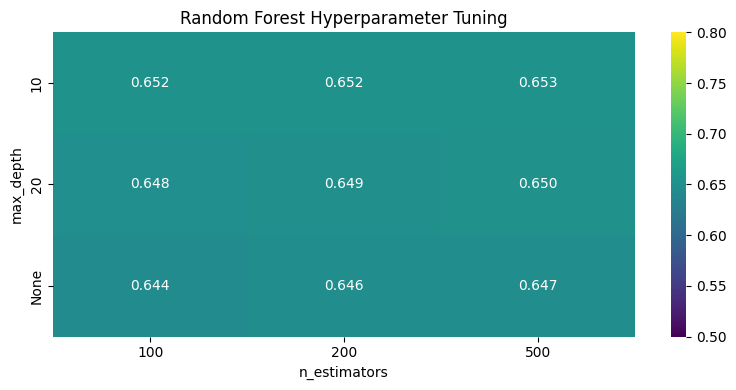

In [ ]:
plot_grid_search(gs_rf, score_label='CV R²', title='Random Forest Hyperparameter Tuning')

In [ ]:
pipe_hgb = Pipeline([
    ('pre', pre),
    ('reg', HistGradientBoostingRegressor(random_state=42, early_stopping=True,)),
])

param_grid_hgb = {
    'reg__learning_rate': [0.01, 0.05, 0.1, 0.5, 1],
}

gs_hgb = GridSearchCV(pipe_hgb, param_grid_hgb, cv=cv, scoring='r2', n_jobs=-1)
gs_hgb.fit(X_train, y_train)

print('HGB best params:', gs_hgb.best_params_)
print('HGB train R²:', gs_hgb.score(X_train, y_train))
print('HGB test  R²:', gs_hgb.score(X_test, y_test))

HGB best params: {'reg__learning_rate': 0.05}
HGB train R²: 0.67429317274342
HGB test  R²: 0.6496612036744662


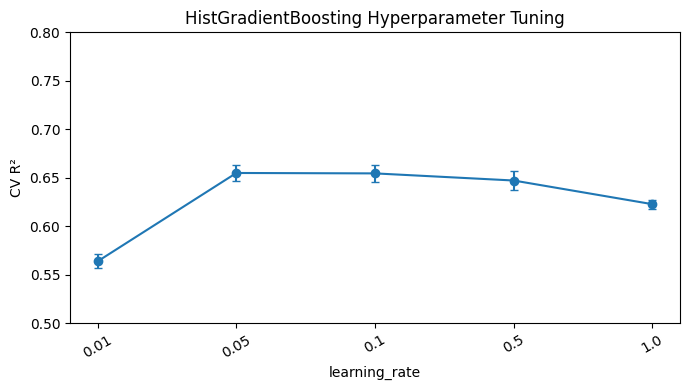

In [ ]:
plot_grid_search(gs_hgb, score_label='CV R²', title='HistGradientBoosting Hyperparameter Tuning')

In [ ]:
pipe_hgb_max = Pipeline([('pre', pre), ('reg', HistGradientBoostingRegressor(
    max_iter=2000, learning_rate=0.02,
    max_depth=None, max_leaf_nodes=127,
    min_samples_leaf=10, random_state=42,
))])
pipe_hgb_max.fit(X_train, y_train)
print('Train R²:', pipe_hgb_max.score(X_train, y_train))
print('Test  R²:', pipe_hgb_max.score(X_test, y_test))

Train R²: 0.7287303493255533
Test  R²: 0.6483428383767434


Best params : {'reg__learning_rate': 0.05}
Best CV R²  : 0.6549
[HistGradientBoostingRegressor]
train R² : 0.6743
test  R² : 0.6497
RMSE     : 8.6372
MSE      : 74.6016


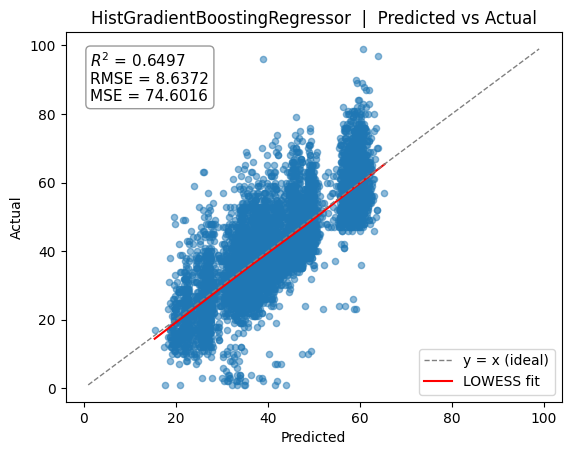

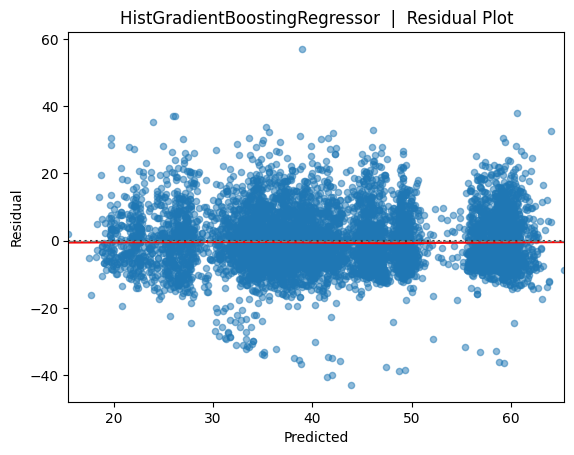

In [228]:
print_regression_results(gs_hgb)

## NN

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(max_iter=1000, random_state=42))
])

mlp_params = {
    "model__hidden_layer_sizes": [
        (10,),
        (50,),
        (100,)
    ],
    "model__alpha": [0.0001, 0.001, 0.01]
}

gs_mlp = GridSearchCV(pipe_mlp, mlp_params, cv=cv, scoring='r2', n_jobs=-1)
gs_mlp.fit(X_train, y_train)

print('MLP best params:', gs_mlp.best_params_)
print('MLP train R²:', gs_mlp.score(X_train, y_train))
print('MLP test  R²:', gs_mlp.score(X_test, y_test))

MLP best params: {'model__alpha': 0.01, 'model__hidden_layer_sizes': (100,)}
MLP train R²: 0.6661159952180862
MLP test  R²: 0.6479571372345292


Best params : {'model__alpha': 0.01, 'model__hidden_layer_sizes': (100,)}
Best CV R²  : 0.6543
[MLPRegressor]
train R² : 0.6661
test  R² : 0.6480
RMSE     : 8.6582
MSE      : 74.9644


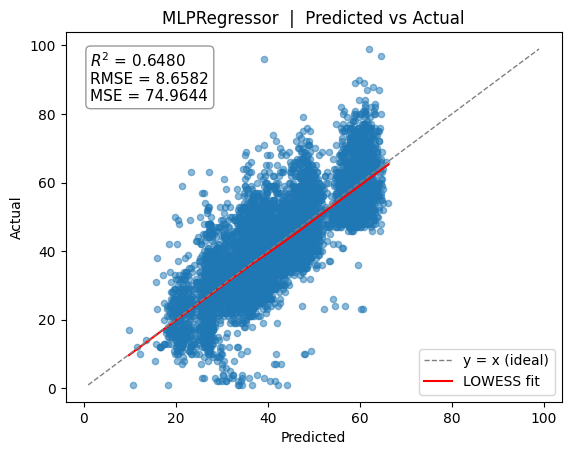

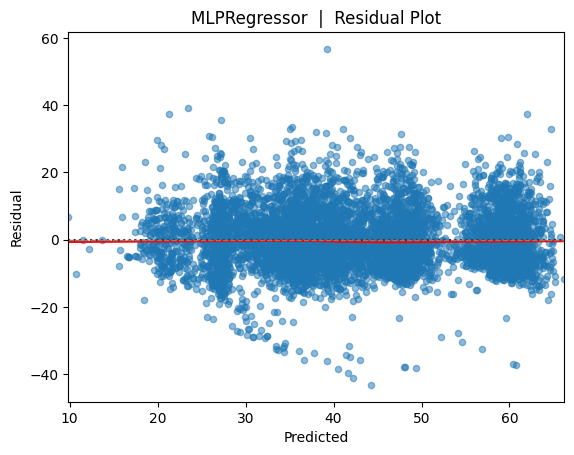

In [231]:
print_regression_results(gs_mlp)

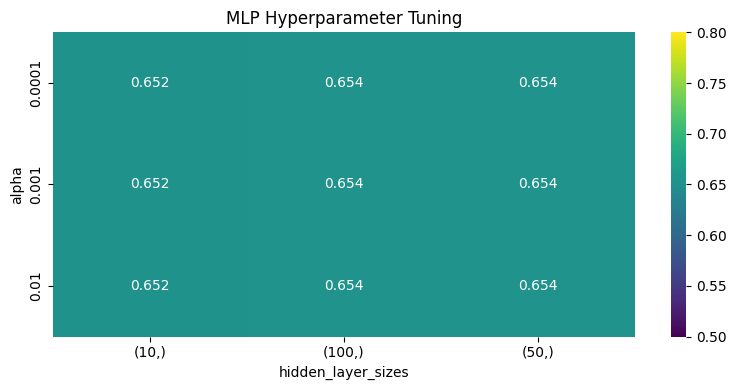

In [ ]:
plot_grid_search(gs_mlp, score_label='CV R²', title='MLP Hyperparameter Tuning')

[Neural Network (no genre)]
train R² : 0.2930
test  R² : 0.2800
RMSE     : 12.3825
MSE      : 153.3270


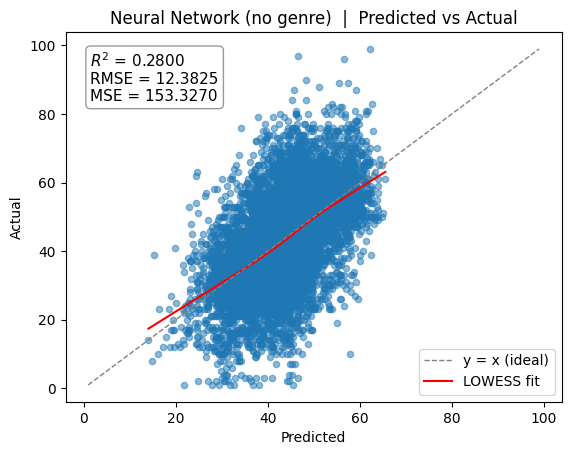

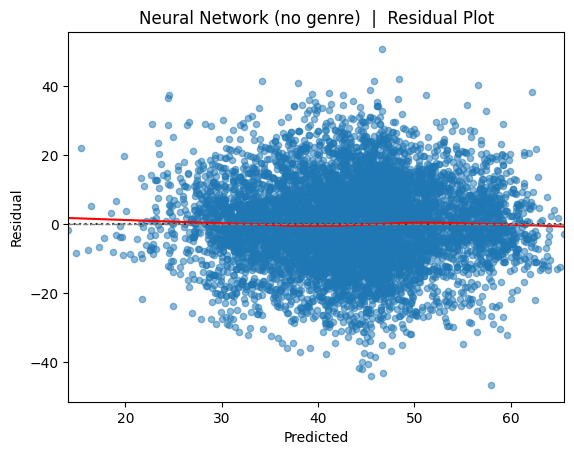

In [243]:
# using without genre features to see how much the genre features contribute to the predictions for tree-based models
pipe_nn_no_genre = Pipeline([
    ('pre', pre_no_genre),
    ('reg', MLPRegressor(max_iter=1000, random_state=42))
])
pipe_nn_no_genre.fit(X_train_no_genre, y_train)
print_regression_results(pipe_nn_no_genre, X_train_no_genre, y_train, X_test_no_genre, y_test, name='Neural Network (no genre)')

## Evaluate

In [ ]:
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error,
)
import numpy as np
import pandas as pd

def evaluate(model, X_test, y_test, name=''):
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'Test R²':   r2_score(y_test, y_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'Test MAE':  mean_absolute_error(y_test, y_pred),
    }

results = pd.DataFrame([
    evaluate(pipe_lr,  X_test, y_test, 'Linear Regression'),
    evaluate(gs_ridge, X_test, y_test, 'Ridge'),
    evaluate(gs_dt,    X_test, y_test, 'Decision Tree'),
    evaluate(gs_rf,    X_test, y_test, 'Random Forest'),
    evaluate(gs_hgb,   X_test, y_test, 'Hist Gradient Boosting'),
    evaluate(gs_mlp,   X_test, y_test, 'MLP'),
    evaluate(pipe_lr_no_genre, X_test_no_genre, y_test, 'Linear Regression (no genre)'),
    evaluate(pipe_nn_no_genre, X_test_no_genre, y_test, 'MLP (no genre)'),
])
results.set_index('Model').round(4)

,Test R²,Test RMSE,Test MAE
Model,,,
Linear Regression,0.6386,8.7730,6.7151
Ridge,0.6386,8.7729,6.7149
Decision Tree,0.6378,8.7825,6.7287
Random Forest,0.6481,8.6559,6.6349
Hist Gradient Boosting,0.6497,8.6372,6.6175
MLP,0.6480,8.6582,6.6531
Linear Regression (no genre),0.2038,13.0206,10.3146
Neural Network (no genre),0.2800,12.3825,9.7587


## Low Dimention


In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score)


In [245]:
features = ['acousticness','danceability','duration_ms','energy','instrumentalness',
            'liveness','loudness','speechiness','tempo','valence']

data = df[features + ['popularity', 'music_genre_orig']].dropna().reset_index(drop=True)
X   = data[features+['popularity']].values
y   = data['music_genre_orig'].values
pop = data['popularity'].values

X_scaled = StandardScaler().fit_transform(X)

In [246]:
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

PCA explained variance ratio: [0.33509567 0.12555414 0.09558925 0.08740279 0.08602819 0.07394969
 0.06794251 0.05449288 0.04084012 0.02315468]


In [247]:
!pip install umap-learn

In [248]:
import umap
X_umap = umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.01,
                    n_jobs=-1).fit_transform(X_scaled)

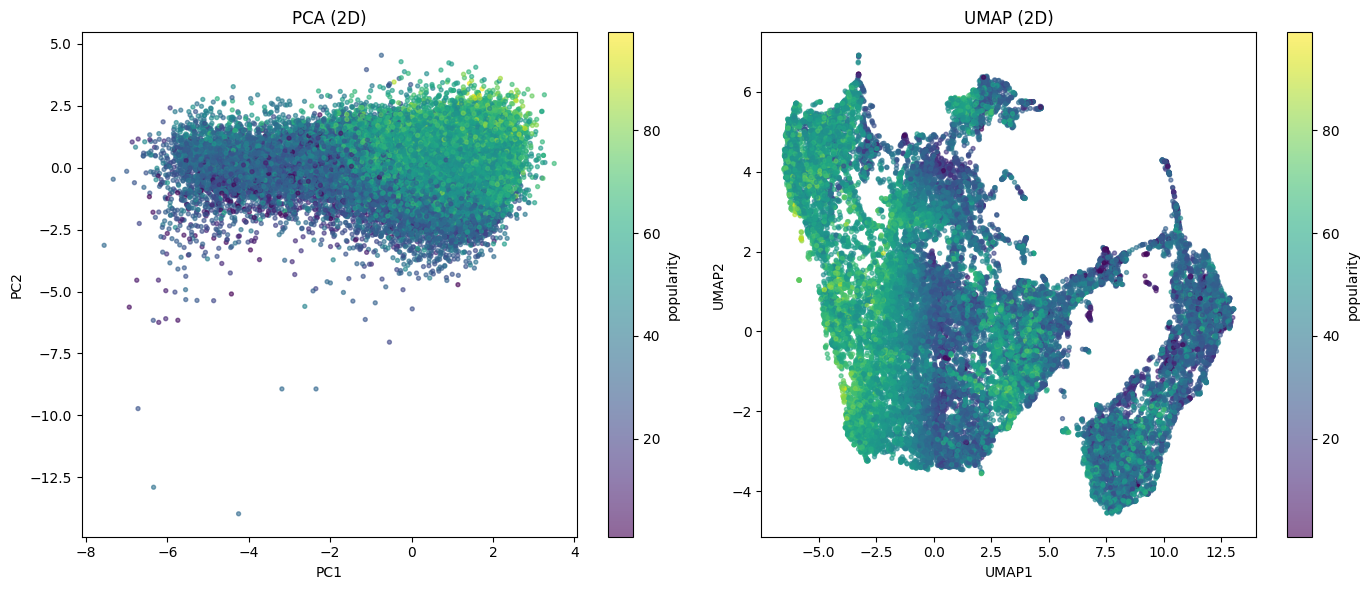

In [249]:
pca_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], c=pop, s=8, cmap='viridis', alpha=0.6)
axes[0].set_title('PCA (2D)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc0, ax=axes[0], label='popularity')

sc1 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=pop, s=8, cmap='viridis', alpha=0.6)
axes[1].set_title('UMAP (2D)')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
plt.colorbar(sc1, ax=axes[1], label='popularity')

plt.tight_layout()
plt.show()

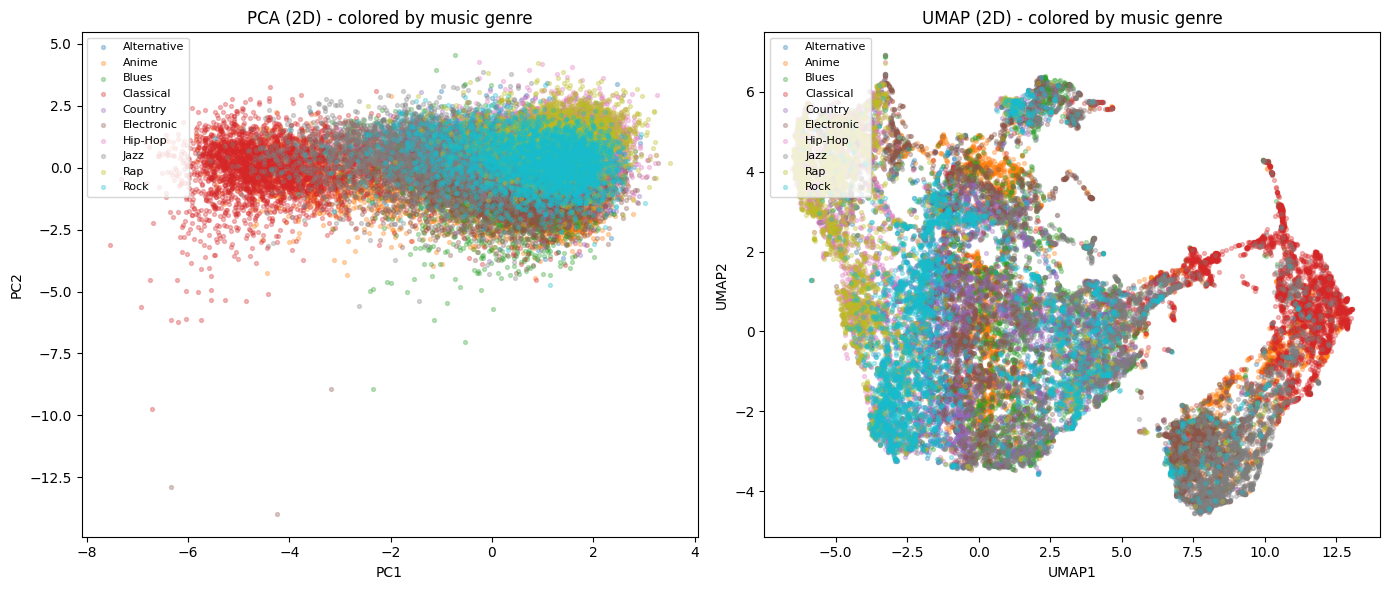

In [253]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

genre_order = np.unique(y)
# PCA colored by genre
for genre in genre_order:
    mask = y == genre
    axes[0].scatter(pca_2d[mask, 0], pca_2d[mask, 1], label=genre, s=8, alpha=0.3)
axes[0].set_title('PCA (2D) - colored by music genre')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(loc='upper left', fontsize=8)

# UMAP colored by genre
for genre in genre_order:
    mask = y == genre
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], label=genre, s=8, alpha=0.3)
axes[1].set_title('UMAP (2D) - colored by music genre')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()